In [ ]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn
import numpy as np
from keras.models import load_model
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from torchvision.models import resnet50
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Download and extract the dataset
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --unzip -p ./real_vs_fake_faces

# Verify that the dataset is downloaded
!ls ./real_vs_fake_faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.74G/3.75G [00:32<00:00, 91.4MB/s]
100% 3.75G/3.75G [00:32<00:00, 125MB/s] 
real_vs_fake  test.csv	train.csv  valid.csv


In [ ]:
class CustomVisionTransformer(nn.Module):
    def __init__(self, image_size=224, patch_size=16, dim=768, depth=12, heads=12, mlp_dim=3072, dropout=0.1):
        super(CustomVisionTransformer, self).__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size"
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2
        self.dim = dim

        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.class_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(batch_size, -1, self.patch_dim)
        x = self.patch_embed(x)

        cls_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        return self.mlp_head(x[:, 0])

class EnhancedCNN(nn.Module):
    def __init__(self, resnet_out_dim=2048):
        super(EnhancedCNN, self).__init__()
        self.resnet_features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Sequential(
                nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(128, resnet_out_dim, kernel_size=3, stride=2, padding=1),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((1, 1))
            )
        )

    def forward(self, x):
        return self.resnet_features(x).view(x.size(0), -1)

class ViTCNNClassifier(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=2,
                 vit_dim=768, resnet_out_dim=2048):
        super().__init__()
        self.vit = CustomVisionTransformer(
            image_size=image_size,
            patch_size=patch_size,
            dim=vit_dim
        )
        self.resnet = EnhancedCNN(resnet_out_dim=resnet_out_dim)

        combined_features = vit_dim + resnet_out_dim
        self.fc = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        vit_out = self.vit(x)
        resnet_out = self.resnet(x)
        combined_out = torch.cat((vit_out, resnet_out), dim=1)
        return self.fc(combined_out)

In [ ]:
class CustomVisionTransformer(nn.Module):
    def __init__(self, image_size=224, patch_size=16, dim=768, depth=12, heads=12, mlp_dim=3072, dropout=0.1):
        super(CustomVisionTransformer, self).__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size"
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2
        self.dim = dim

        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.class_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(batch_size, -1, self.patch_dim)
        x = self.patch_embed(x)

        cls_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        return self.mlp_head(x[:, 0])

# Enhanced ResNet using ResNet50
class EnhancedResNet(nn.Module):
    def __init__(self, resnet_out_dim=2048):
        super(EnhancedResNet, self).__init__()
        # Load ResNet50 with pretrained weights
        resnet = resnet50(pretrained=True)
        # Remove the fully connected layer (fc) and replace with identity
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-1])
        self.out_dim = resnet_out_dim

    def forward(self, x):
        x = self.resnet_features(x)
        return x.view(x.size(0), -1)

# Combined ViT and ResNet Model
class ViTResNetClassifier(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=2,
                 vit_dim=768, resnet_out_dim=2048):
        super().__init__()
        self.vit = CustomVisionTransformer(
            image_size=image_size,
            patch_size=patch_size,
            dim=vit_dim
        )
        self.resnet = EnhancedResNet(resnet_out_dim=resnet_out_dim)

        combined_features = vit_dim + resnet_out_dim
        self.fc = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        vit_out = self.vit(x)
        resnet_out = self.resnet(x)
        combined_out = torch.cat((vit_out, resnet_out), dim=1)
        return self.fc(combined_out)

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.BatchNorm2d(3),  # Assuming input_shape=(None, 3, H, W)

            # First Convolutional Block
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(16),

            # Second Convolutional Block
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(32),
            nn.Dropout(0.1),

            # Third Convolutional Block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(64),
            nn.Dropout(0.1),

            # Fourth Convolutional Block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout(0.1),

            # Fifth Convolutional Block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(256),
            nn.Dropout(0.1),

            # Sixth Convolutional Block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(512),
            nn.Dropout(0.1),

            # Final Convolutional Block
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(1024),
            nn.Dropout(0.1),

            # Flatten and Fully Connected Layer
            nn.Flatten(),
            nn.Linear(1024, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Define a simplified model using only ResNet50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet50Classifier, self).__init__()
        self.resnet = resnet50(pretrained=True)
        # Replace the final layer to match the number of classes
        self.resnet.fc = nn.Sequential(
            nn.Linear(self.resnet.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [ ]:
# Custom Vision Transformer (unchanged)
class CustomVisionTransformer(nn.Module):
    def __init__(self, image_size=224, patch_size=16, dim=768, depth=12, heads=12, mlp_dim=3072, dropout=0.1):
        super(CustomVisionTransformer, self).__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size"
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2
        self.dim = dim

        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.class_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(batch_size, -1, self.patch_dim)
        x = self.patch_embed(x)

        cls_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        return self.mlp_head(x[:, 0])

# ViT Classifier
class VisionTransformerClassifier(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=2, vit_dim=768):
        super(VisionTransformerClassifier, self).__init__()
        self.vit = CustomVisionTransformer(
            image_size=image_size,
            patch_size=patch_size,
            dim=vit_dim
        )

        self.fc = nn.Sequential(
            nn.Linear(vit_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        vit_out = self.vit(x)  # Use only ViT output
        return self.fc(vit_out)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-26-4b24e95d310d>:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more deta

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


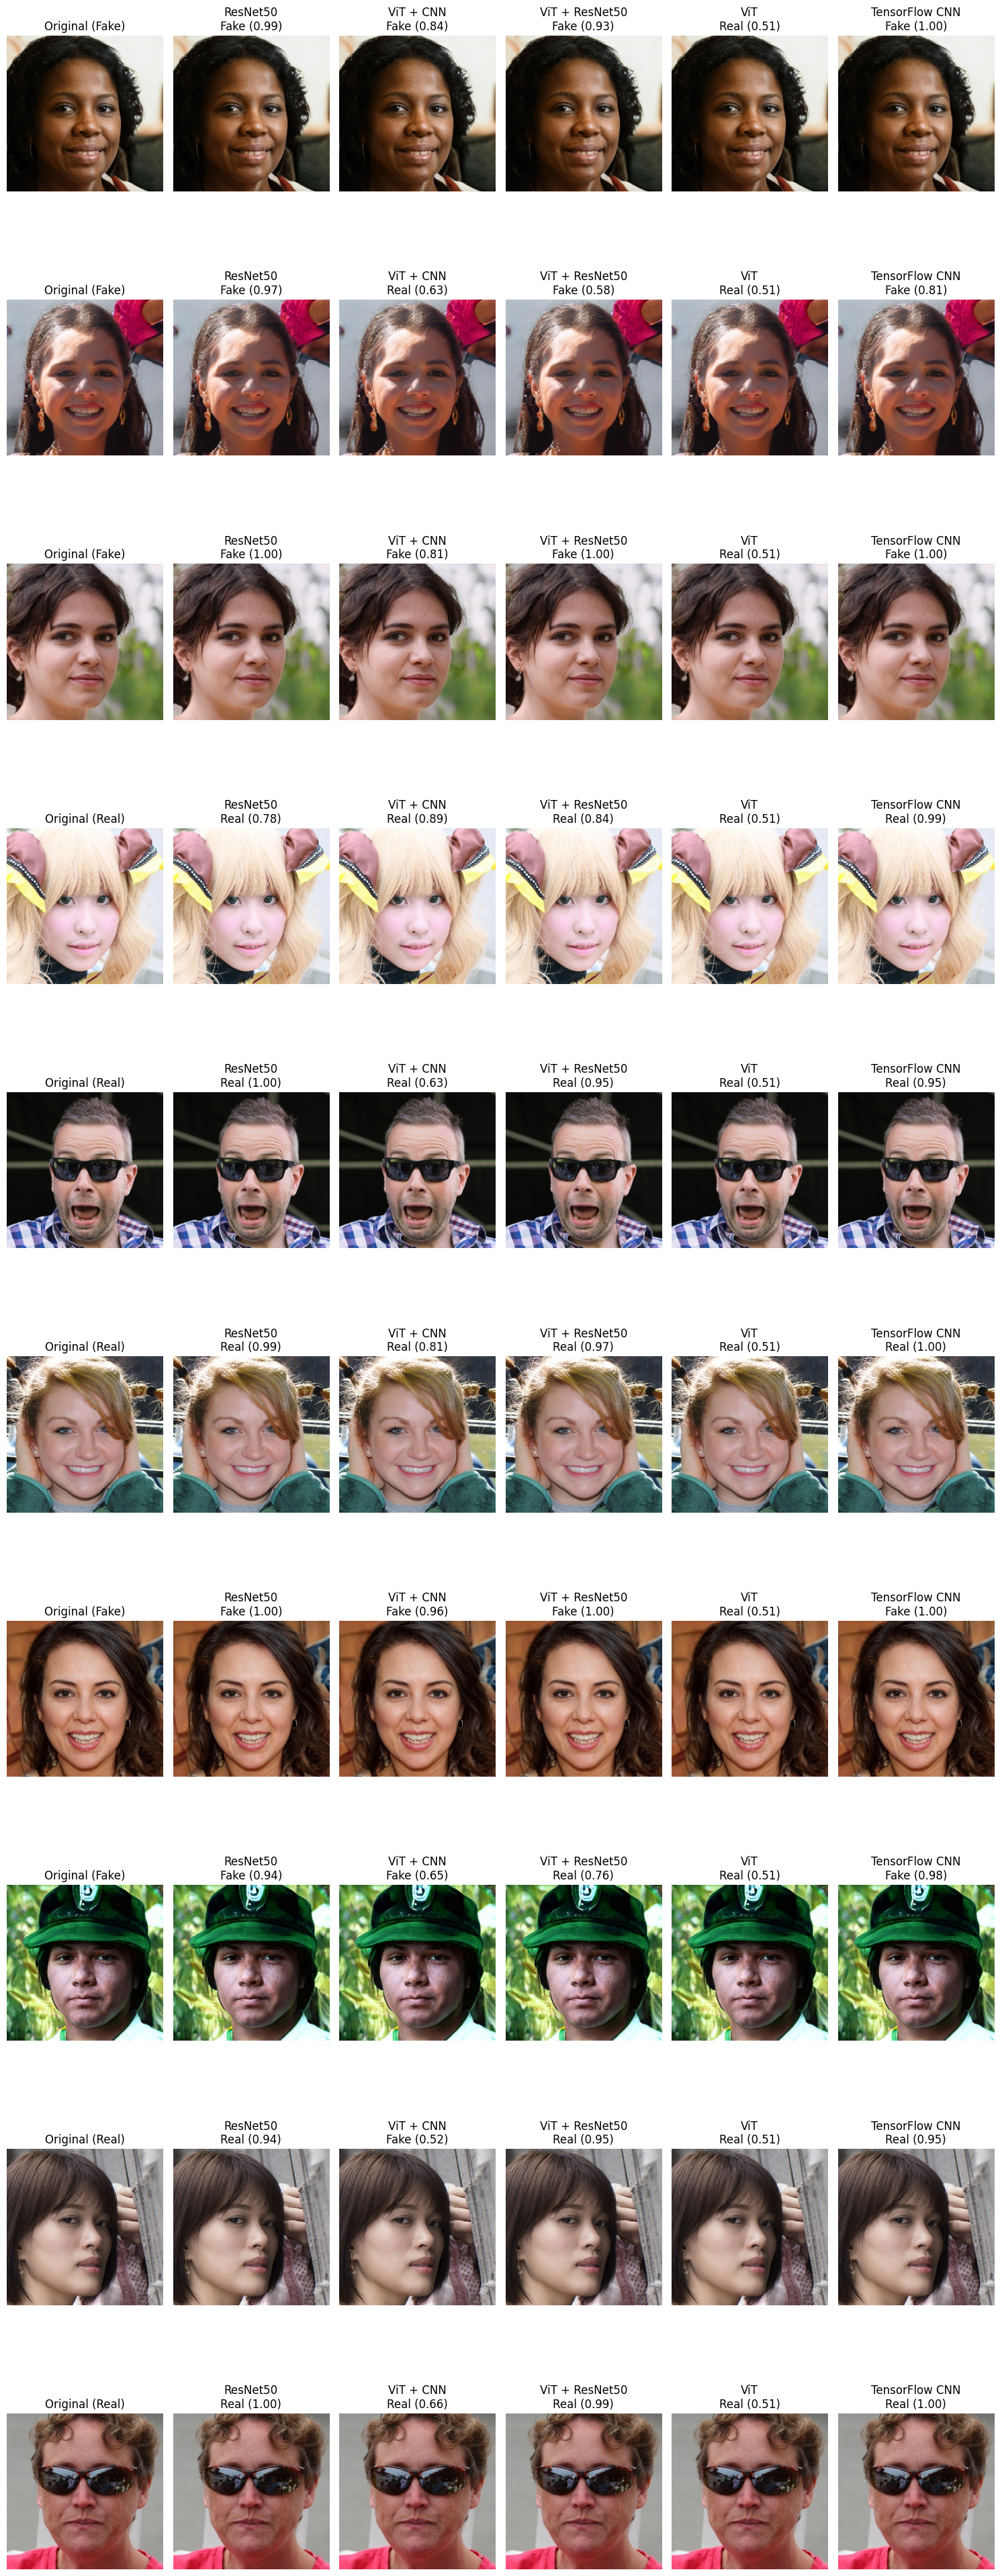

In [ ]:
# --- Data Transformations ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load Pretrained Models ---
def load_model(model_class, weight_path, device="cpu"):
    model = model_class()
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.eval()
    return model.to(device)

def load_tf_model(h5_path):
    """Load a TensorFlow model from a .h5 file."""
    model = tf.keras.models.load_model(h5_path)
    return model

def predict_single_image(model, image_path, device, transform):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    return predicted_class, confidence

def predict_single_image_tf(model, image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    predictions = model.predict(image)
    predicted_class = 0 if predictions[0][0] < 0.5 else 1
    confidence = predictions[0][0] if predictions[0][0] >= 0.5 else 1 - predictions[0][0]
    return predicted_class, confidence

# --- Predict and Visualize ---
def predict_and_visualize(models, image_paths, device, transform, class_names):
    plt.figure(figsize=(15, len(image_paths) * 4))
    results = []
    real = '/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/test/real/'
    fake = '/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/test/fake/'

    for idx, image_path in enumerate(image_paths):
        # Identify original class from file path
        original_class = "Fake" if fake in image_path else "Real"

        # Load and show original image
        image = Image.open(image_path).convert('RGB')
        plt.subplot(len(image_paths), len(models) + 1, idx * (len(models) + 1) + 1)
        plt.imshow(np.array(image))
        plt.title(f"Original ({original_class})")
        plt.axis('off')

        row_results = []
        for model_idx, (model_name, model) in enumerate(models.items(), start=1):
            # Predict using the appropriate model type
            if isinstance(model, tf.keras.Model):  # TensorFlow Model
                pred_class, confidence = predict_single_image_tf(model, image_path)
            else:  # PyTorch Model
                pred_class, confidence = predict_single_image(model, image_path, device, transform)

            predicted_label = class_names[pred_class]
            row_results.append((model_name, predicted_label, confidence))

            # Show the prediction result
            plt.subplot(len(image_paths), len(models) + 1, idx * (len(models) + 1) + model_idx + 1)
            plt.imshow(np.array(image))
            plt.title(f"{model_name}\n{predicted_label} ({confidence:.2f})")
            plt.axis('off')

        results.append((image_path, row_results))
    plt.tight_layout()
    plt.show()
    return results

# --- Main Execution ---
if __name__ == "__main__":
    # Configurations
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_names = ['Fake', 'Real']
    model_weights = {
        "ResNet50": "ResNet50.pth",
        "ViT + CNN": "ViT + CNN.pth",
        "ViT + ResNet50": "ViT + ResNet50.pth",
        "ViT": "ViT.pth",
        "TensorFlow CNN": "CNN.h5"  # Add the TensorFlow model
    }

    # Define Models
    model_classes = {
        "ResNet50": ResNet50Classifier,  # Define ResNet50Classifier
        "ViT + CNN": ViTCNNClassifier,   # Define ViTCNNClassifier
        "ViT + ResNet50": ViTResNetClassifier,
        "ViT": VisionTransformerClassifier  # Define VisionTransformerClassifier
    }

    # Load Models
    models = {}
    for name, path in model_weights.items():
        if path.endswith('.h5'):  # TensorFlow Model
            models[name] = load_tf_model(path)
        else:  # PyTorch Model
            models[name] = load_model(model_classes[name], path, device=device)

    # Random test images from both "fake" and "real" directories
    test_image_dir = "/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/test"
    fake_images = [os.path.join(test_image_dir, 'fake', f) for f in os.listdir(os.path.join(test_image_dir, 'fake')) if f.endswith(('.jpg', '.png'))]
    real_images = [os.path.join(test_image_dir, 'real', f) for f in os.listdir(os.path.join(test_image_dir, 'real')) if f.endswith(('.jpg', '.png'))]

    # Randomly select images from both classes
    selected_fake_images = random.sample(fake_images, min(5, len(fake_images)))
    selected_real_images = random.sample(real_images, min(5, len(real_images)))
    random_images = selected_fake_images + selected_real_images
    random.shuffle(random_images)  # Shuffle the images for variety

    # Predict and Visualize
    prediction_results = predict_and_visualize(models, random_images, device, transform, class_names)


In [ ]:
# --- Evaluate Model ---
def evaluate_model(model, dataloader, device, class_names):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Metrics
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    conf_matrix = confusion_matrix(y_true, y_pred)
    return report, conf_matrix

def evaluate_tf_model(model, dataloader, class_names):
    y_pred = model.predict(dataloader)
    y_test = dataloader.classes
    conf_matrix = confusion_matrix(y_test, y_pred > 0.5)
    report = classification_report(y_test, y_pred > 0.5)
    return report, conf_matrix


# Load Test Dataset for PyTorch Models
for model_name, model in models.items():
    if isinstance(model, tf.keras.Model):  # TensorFlow Model
        # print(f"Evaluating {model_name} (TensorFlow)")
        image_gen = ImageDataGenerator(rescale=1./255.)
        test_flow = image_gen.flow_from_directory('/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/' + 'test/', target_size=(224, 224), batch_size=64, shuffle=False, class_mode='binary')
        report, conf_matrix = evaluate_tf_model(model, test_flow, class_names)
        print(f"\n--- {model_name} Classification Report ---\n{report}")
        print(f"Confusion Matrix:\n{conf_matrix}")
    else:  # PyTorch Model
        # print(f"Evaluating {model_name} (PyTorch)")
        test_dataset = datasets.ImageFolder(root="/content/real_vs_fake_faces/real_vs_fake/real-vs-fake/test", transform=transform)
        dataloaders = {"test": DataLoader(test_dataset, batch_size=32, shuffle=False)}
        report, conf_matrix = evaluate_model(model, dataloaders["test"], device, class_names)
        print(f"\n--- {model_name} Classification Report ---\n{report}")
        print(f"\nConfusion Matrix:\n{conf_matrix} \n")



--- ResNet50 Classification Report ---
              precision    recall  f1-score   support

        Fake     0.9663    0.9982    0.9820     10000
        Real     0.9981    0.9652    0.9814     10000

    accuracy                         0.9817     20000
   macro avg     0.9822    0.9817    0.9817     20000
weighted avg     0.9822    0.9817    0.9817     20000


Confusion Matrix:
[[9982   18]
 [ 348 9652]] 


--- ViT + CNN Classification Report ---
              precision    recall  f1-score   support

        Fake     0.9443    0.8933    0.9181     10000
        Real     0.8988    0.9473    0.9224     10000

    accuracy                         0.9203     20000
   macro avg     0.9215    0.9203    0.9202     20000
weighted avg     0.9215    0.9203    0.9202     20000


Confusion Matrix:
[[8933 1067]
 [ 527 9473]] 


--- ViT + ResNet50 Classification Report ---
              precision    recall  f1-score   support

        Fake     0.9927    0.9938    0.9933     10000
        Real  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- ViT Classification Report ---
              precision    recall  f1-score   support

        Fake     0.0000    0.0000    0.0000     10000
        Real     0.5000    1.0000    0.6667     10000

    accuracy                         0.5000     20000
   macro avg     0.2500    0.5000    0.3333     20000
weighted avg     0.2500    0.5000    0.3333     20000


Confusion Matrix:
[[    0 10000]
 [    0 10000]] 

Found 20000 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 145ms/step

--- TensorFlow CNN Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     10000
           1       0.98      0.87      0.92     10000

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000

Confusion Matrix:
[[9864  136]
 [1281 8719]]


## NOTE
The Data from Training, Validation and Comparsion Metrics are hardcoded whose value are derived from the codes executed, this is just done for the ease of plotting graphs for the report, and beacuse the validation and training accuracy would not be available here. This can be verified by comparing the values with the results derived.

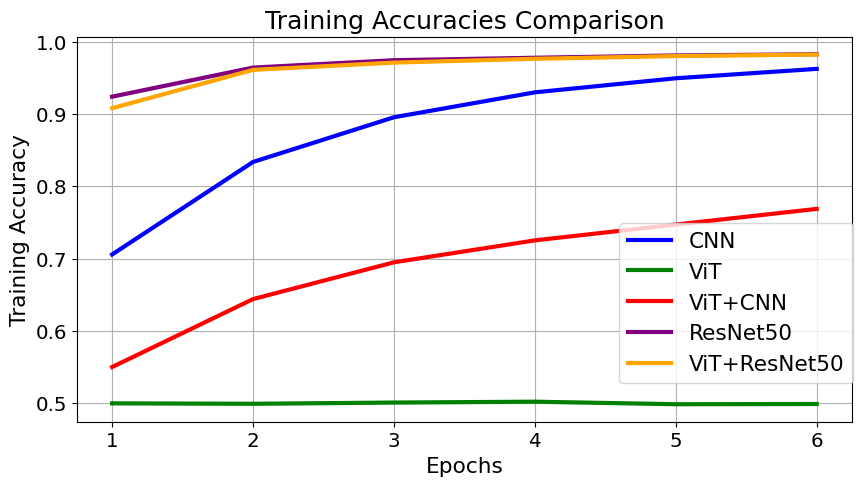

In [ ]:
# Training Accuracies across all the models
import matplotlib.pyplot as plt

# Manually copy-pasting the recorded Training Accuracies across all the 5 models
epochs = [1, 2, 3, 4, 5, 6]
graph1 = [0.7056, 0.8337, 0.8956, 0.9301, 0.9496, 0.9626]
graph2 = [0.4994, 0.4988, 0.5005, 0.5017, 0.4982, 0.4985]
graph3 = [0.5497, 0.6438, 0.6947, 0.7251, 0.7470, 0.7687]
graph4 = [0.9241, 0.9644, 0.9746, 0.9780, 0.9812, 0.9829]
graph5 = [0.9082, 0.9612, 0.9713, 0.9766, 0.9803, 0.9825]

# Plot Training Accuracies Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs, graph1, label='CNN', color='blue', linewidth=3)
plt.plot(epochs, graph2, label='ViT', color='green', linewidth=3)
plt.plot(epochs, graph3, label='ViT+CNN', color='red', linewidth=3)
plt.plot(epochs, graph4, label='ResNet50', color='purple', linewidth=3)
plt.plot(epochs, graph5, label='ViT+ResNet50', color='orange', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracies Comparison')
plt.legend(loc=(0.7, 0.1))
plt.grid(True)
plt.show()

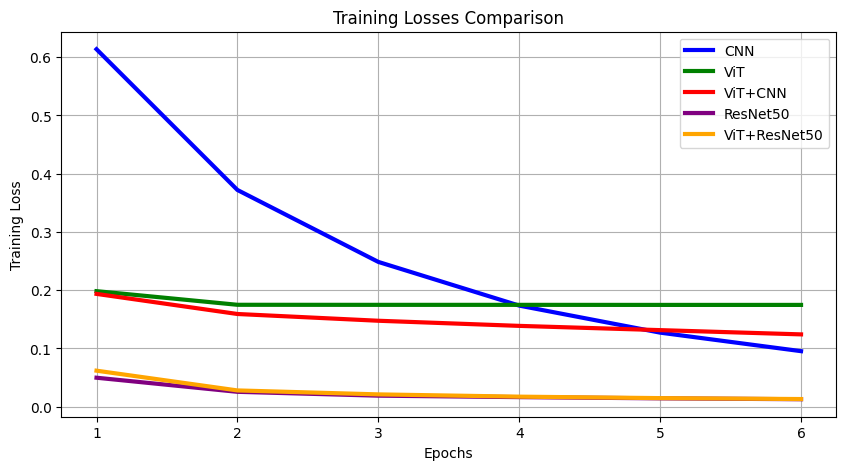

In [ ]:
# Training losses
import matplotlib.pyplot as plt

# Manually copy-pasting the recorded Training Losses across all the 5 models
epochs = [1, 2, 3, 4, 5, 6]
graph1 = [0.6136, 0.3720, 0.2485, 0.1735, 0.1271, 0.0953]
graph2 = [0.1983, 0.1749, 0.1748, 0.1748, 0.1747, 0.1747]
graph3 = [0.1936, 0.1591, 0.1475, 0.1387, 0.1314, 0.1241]
graph4 = [0.0497, 0.0255, 0.0189, 0.0164, 0.0143, 0.0128]
graph5 = [0.0618, 0.0279, 0.0211, 0.0172, 0.0147, 0.0131]

# Plot Training Accuracies Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs, graph1, label='CNN', color='blue', linewidth=3)
plt.plot(epochs, graph2, label='ViT', color='green', linewidth=3)
plt.plot(epochs, graph3, label='ViT+CNN', color='red', linewidth=3)
plt.plot(epochs, graph4, label='ResNet50', color='purple', linewidth=3)
plt.plot(epochs, graph5, label='ViT+ResNet50', color='orange', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Losses Comparison')
plt.legend(loc='best')
plt.grid(True)
plt.show()


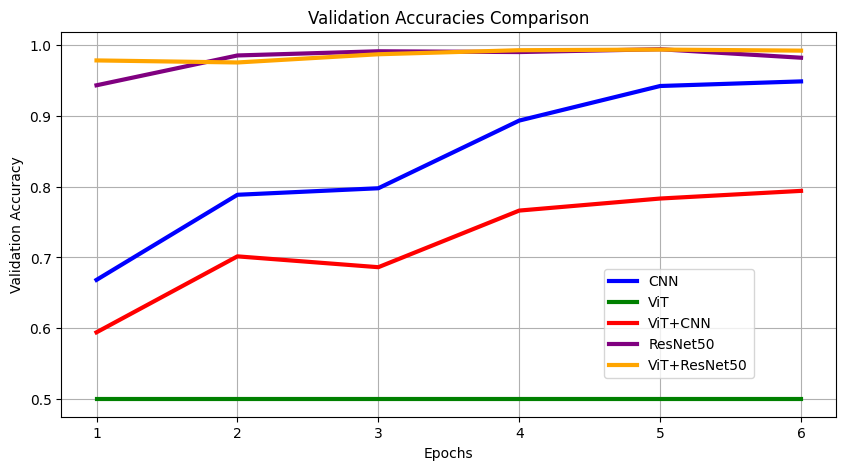

In [ ]:
# Validation Accuracies
import matplotlib.pyplot as plt

# Manually copy-pasting the recorded Validation Accuracies across all the 5 models
epochs = [1, 2, 3, 4, 5, 6]
graph1 = [0.6684, 0.7885, 0.7977, 0.8932, 0.9420, 0.9485]
graph2 = [0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000]
graph3 = [0.5944, 0.7016, 0.6863, 0.7662, 0.7832, 0.7940]
graph4 = [0.9430, 0.9851, 0.9910, 0.9899, 0.9939, 0.9819]
graph5 = [0.9781, 0.9752, 0.9868, 0.9925, 0.9934, 0.9919]

# Plot Training Accuracies Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs, graph1, label='CNN', color='blue', linewidth=3)
plt.plot(epochs, graph2, label='ViT', color='green', linewidth=3)
plt.plot(epochs, graph3, label='ViT+CNN', color='red', linewidth=3)
plt.plot(epochs, graph4, label='ResNet50', color='purple', linewidth=3)
plt.plot(epochs, graph5, label='ViT+ResNet50', color='orange', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracies Comparison')
plt.legend(loc=(0.7, 0.1))
plt.grid(True)
plt.show()

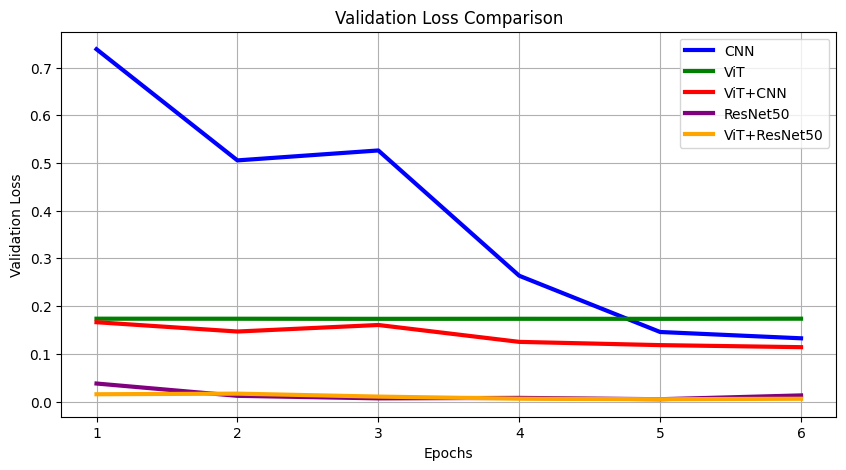

In [ ]:
# Validation Losses
import matplotlib.pyplot as plt

# Manually copy-pasting the recorded Validation Losses across all the 5 models
epochs = [1, 2, 3, 4, 5, 6]
graph1 = [0.7384, 0.5054, 0.5262, 0.2636, 0.1457, 0.1325]
graph2 = [0.1736, 0.1735, 0.1733, 0.1734, 0.1733, 0.1736]
graph3 = [0.1662, 0.1467, 0.1604, 0.1250, 0.1182, 0.1139]
graph4 = [0.0377, 0.0119, 0.0066, 0.0076, 0.0048, 0.0128]
graph5 = [0.0152, 0.0165, 0.0103, 0.0059, 0.0048, 0.0058]

# Plot Validation Losses Comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs, graph1, label='CNN', color='blue', linewidth=3)
plt.plot(epochs, graph2, label='ViT', color='green', linewidth=3)
plt.plot(epochs, graph3, label='ViT+CNN', color='red', linewidth=3)
plt.plot(epochs, graph4, label='ResNet50', color='purple', linewidth=3)
plt.plot(epochs, graph5, label='ViT+ResNet50', color='orange', linewidth=3)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation  Comparison')
plt.legend(loc='best')
plt.grid(True)
plt.show()

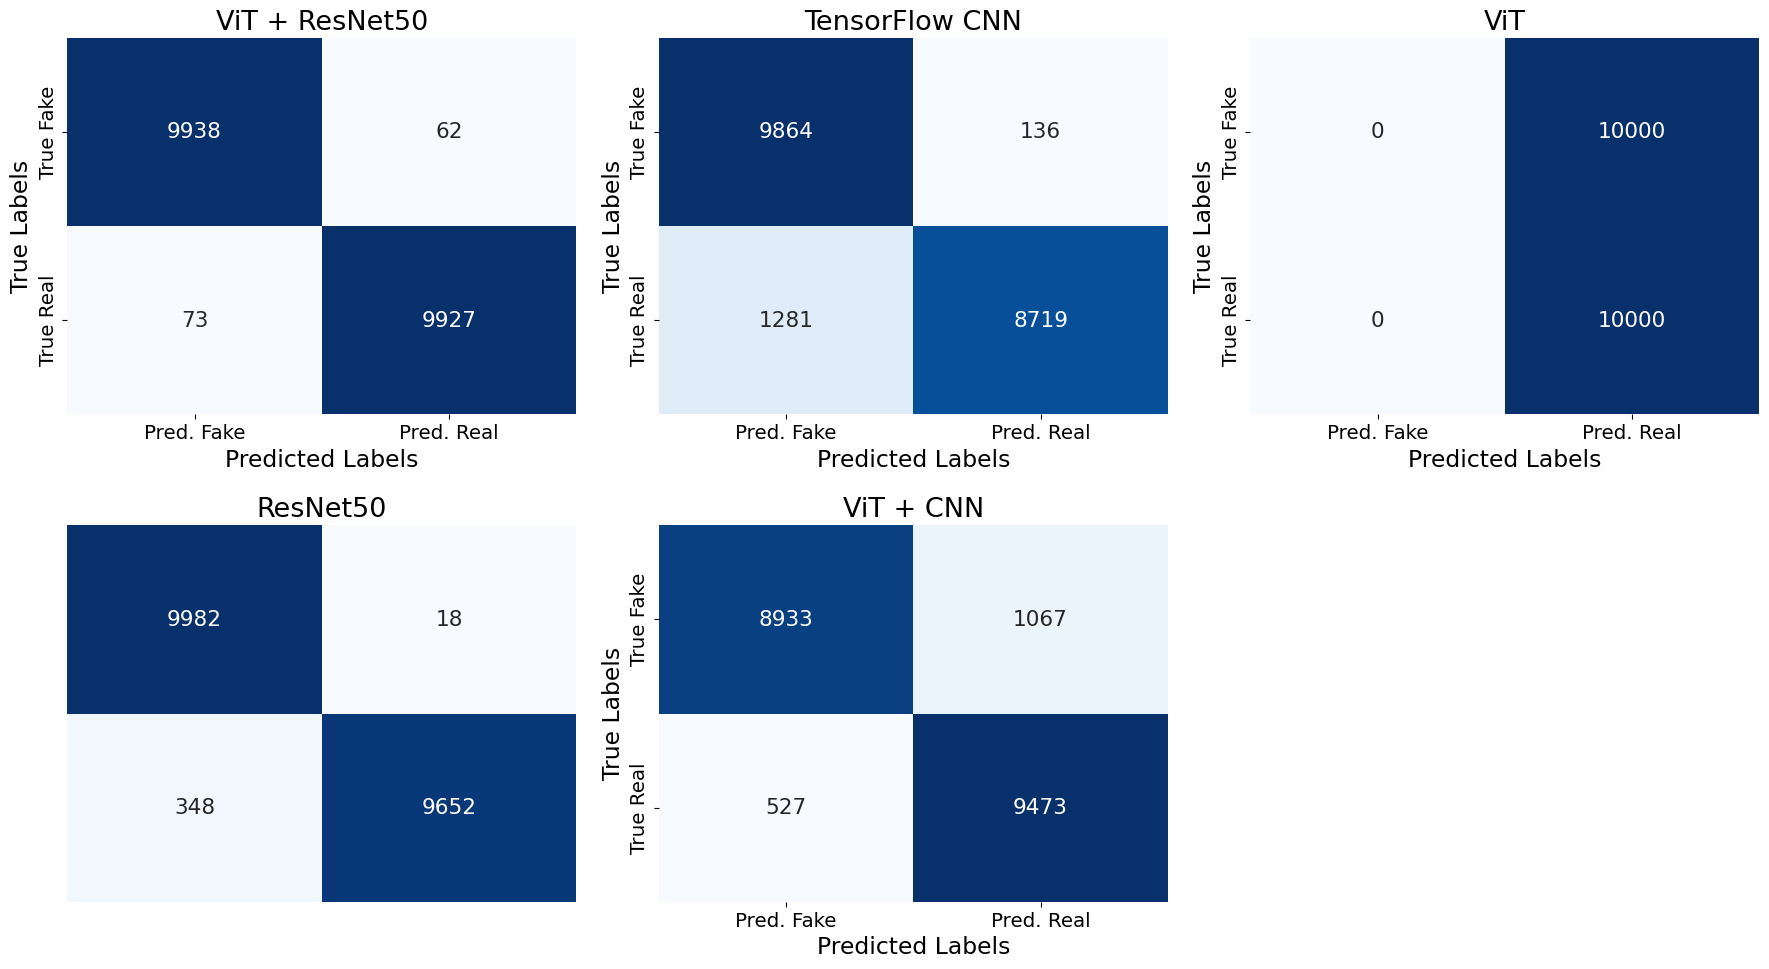

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Increase font size globally by 30%
plt.rcParams.update({
    'font.size': 13 * 1.3,        # Base font size
    'axes.titlesize': 15 * 1.3,   # Title font size
    'axes.labelsize': 13 * 1.3,   # Axis labels
    'xtick.labelsize': 11 * 1.3,  # X-axis tick labels
    'ytick.labelsize': 11 * 1.3   # Y-axis tick labels
})

# Manually copy-pasting the recorded Confusion Matrices across all the 5 models
conf_matrix_1 = np.array([[9938, 62], [73, 9927]])
conf_matrix_2 = np.array([[9864, 136], [1281, 8719]])
conf_matrix_3 = np.array([[0, 10000], [0, 10000]])
conf_matrix_4 = np.array([[9982, 18], [348, 9652]])
conf_matrix_5 = np.array([[8933, 1067], [527, 9473]])

# List of matrices and titles
conf_matrices = [conf_matrix_1, conf_matrix_2, conf_matrix_3, conf_matrix_4, conf_matrix_5]
titles = ['ViT + ResNet50', 'TensorFlow CNN', 'ViT', 'ResNet50', 'ViT + CNN']


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot the first row (3 plots)
for i in range(3):
    sns.heatmap(conf_matrices[i], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred. Fake', 'Pred. Real'],
                yticklabels=['True Fake', 'True Real'],
                ax=axes[i], cbar=False, annot_kws={"size": 12 * 1.3})
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Predicted Labels')
    axes[i].set_ylabel('True Labels')

# Clear the first and last axes in the second row for centering
axes[3].axis('off')  # Left empty axis
axes[5].axis('off')  # Right empty axis

# Plot the centered second-row confusion matrices
for i, j in zip([3, 4], [4, 5]):
    sns.heatmap(conf_matrices[i], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred. Fake', 'Pred. Real'],
                yticklabels=['True Fake', 'True Real'],
                ax=axes[j-1], cbar=False, annot_kws={"size": 12 * 1.3})
    axes[j-1].set_title(titles[i])
    axes[j-1].set_xlabel('Predicted Labels')
    axes[j-1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()
